
RQ6 TABLE:

          Metric     Value
0  Mean Accuracy  0.826067
1  Std Deviation  0.004892


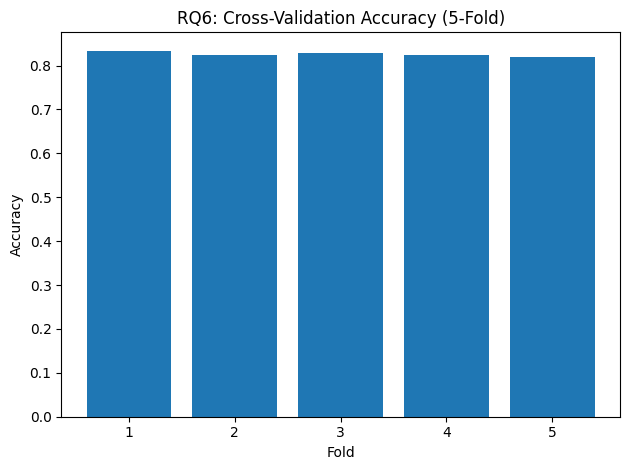


Files saved in: C:\Users\vishwa\kidney disease prediction/outputs/


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier


# =========================
# 0. OUTPUT FOLDER
# =========================
os.makedirs("outputs", exist_ok=True)


# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv("kidney_disease_balanced.csv")
df.replace('?', np.nan, inplace=True)


# =========================
# 2. SPLIT TARGET
# =========================
y = df["Target"]
X = df.drop("Target", axis=1)


# =========================
# 3. DETECT COLUMNS
# =========================
cat_cols = X.select_dtypes(include=['str']).columns

if len(cat_cols) == 0:
    cat_cols = X.select_dtypes(include=['str']).columns

num_cols = X.columns.difference(cat_cols)


# =========================
# 4. PREPROCESSING
# =========================
# Impute
X[num_cols] = SimpleImputer(strategy='mean').fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])

# Encode categorical
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col])

# Encode target
y = LabelEncoder().fit_transform(y)

# Scale
X = StandardScaler().fit_transform(X)


# =========================
# 5. MODEL
# =========================
model = RandomForestClassifier()


# =========================
# 6. CROSS VALIDATION
# =========================
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

mean_acc = scores.mean()
std_acc = scores.std()


# =========================
# 7. CREATE TABLE
# =========================
df_out = pd.DataFrame({
    "Metric": ["Mean Accuracy", "Std Deviation"],
    "Value": [mean_acc, std_acc]
})

df_out.to_csv("outputs/RQ6_table.csv", index=False)

print("\nRQ6 TABLE:\n")
print(df_out)


# =========================
# 8. CREATE FIGURE
# =========================
plt.figure()

plt.bar(range(1, 6), scores)

plt.title("RQ6: Cross-Validation Accuracy (5-Fold)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")

plt.tight_layout()

plt.savefig("outputs/RQ6_figure.pdf")

plt.show()


# =========================
# 9. CONFIRM SAVE
# =========================
print("\nFiles saved in:", os.getcwd() + "/outputs/")